## Exploratory Analisys

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import io

In [46]:
data = pd.read_csv('sensors.csv', sep = ',')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6928 entries, 0 to 6927
Data columns (total 95 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 6927 non-null   object 
 1   Total Voltage (V)    6927 non-null   object 
 2   Average Voltage (V)  6927 non-null   float64
 3   sensor 1             6927 non-null   float64
 4   sensor 2             6927 non-null   float64
 5   sensor 3             6927 non-null   float64
 6   sensor 4             6927 non-null   float64
 7   sensor 5             6927 non-null   float64
 8   sensor 6             6927 non-null   float64
 9   sensor 7             6927 non-null   float64
 10  sensor 8             6927 non-null   float64
 11  sensor 9             6927 non-null   float64
 12  sensor 10            6927 non-null   float64
 13  sensor 11            6927 non-null   float64
 14  sensor 12            6927 non-null   float64
 15  sensor 13            6927 non-null   f

In [47]:
#Dropping columns that are not relevant for the model  
data = data.drop(columns = ['Total Voltage (V)', 'Average Voltage (V)'])

#Converting the 'Date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)


#Checking the first few rows of the updated dataset
data.head(3)

,Date,sensor 1,sensor 2,sensor 3,sensor 4,sensor 5,sensor 6,sensor 7,sensor 8,sensor 9,...,sensor 83,sensor 84,sensor 85,sensor 86,sensor 87,sensor 88,sensor 89,sensor 90,sensor 91,sensor 92
0,2023-04-03 03:00:01,119.121812,115.827723,116.327884,117.658852,117.589612,117.496657,115.859532,114.603809,118.058141,...,115.647812,114.299245,116.471634,115.380364,115.110607,115.910664,117.049984,114.031306,113.770388,115.565692
1,2023-04-03 04:00:01,121.092423,117.628034,118.118468,119.575351,119.504139,119.387818,117.598619,116.261870,119.998991,...,117.329442,115.892439,118.243012,117.071528,116.750911,117.634598,118.956594,115.616289,115.338720,117.255179
2,2023-04-03 05:00:01,121.893561,118.410648,118.866724,120.405980,120.332878,120.213393,118.315624,116.951690,120.807357,...,118.087727,116.615680,119.053043,117.826122,117.492186,118.392878,119.695606,116.356843,116.066697,118.036934


The fig above show when the site shutdown, and thats it's not a good messure to bring to the model

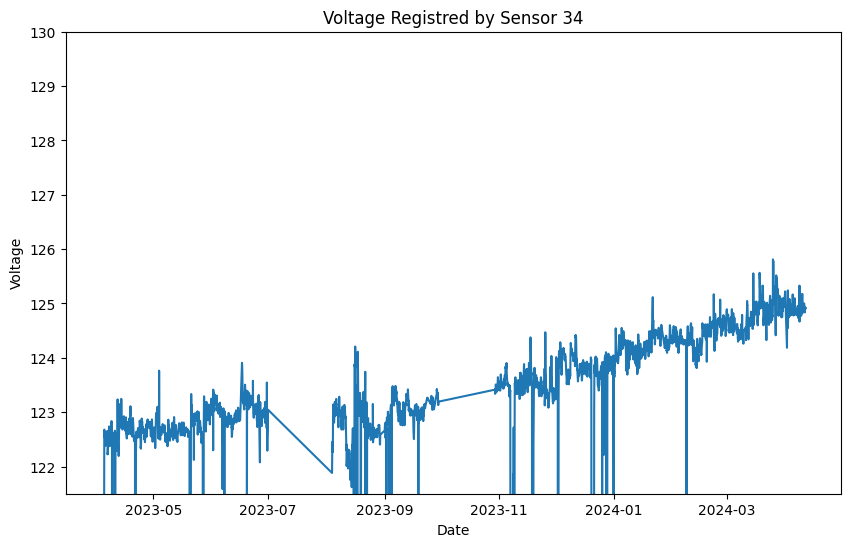

In [48]:
plt.figure(figsize=(10, 6))
sns.lineplot(data = data, y='sensor 34', x='Date')
plt.title('Voltage Registred by Sensor 34')
plt.ylim(121.5, 130)
plt.xlabel('Date')
plt.ylabel('Voltage')
plt.show()

In [49]:
data = data[data['sensor 34'] > 121.5 ]
data['sensor 34'].describe()

count    6658.000000
mean      123.555389
std         0.805674
min       121.585035
25%       122.852568
50%       123.424118
75%       124.263571
max       125.811034
Name: sensor 34, dtype: float64

In [50]:
average_s34 = data.groupby(data['Date'].dt.date)['sensor 34'].mean()
average_s34 = average_s34.reset_index()
average_s34.rename(columns={'Date': 'average_daily'}, inplace=True)
average_s34

,average_daily,sensor 34
0,2023-04-04,122.444449
1,2023-04-05,122.511457
2,2023-04-06,122.462247
3,2023-04-07,122.558795
4,2023-04-08,122.635337
...,...,...
301,2024-04-07,124.854037
302,2024-04-08,125.114604
303,2024-04-09,124.935289
304,2024-04-10,124.929781


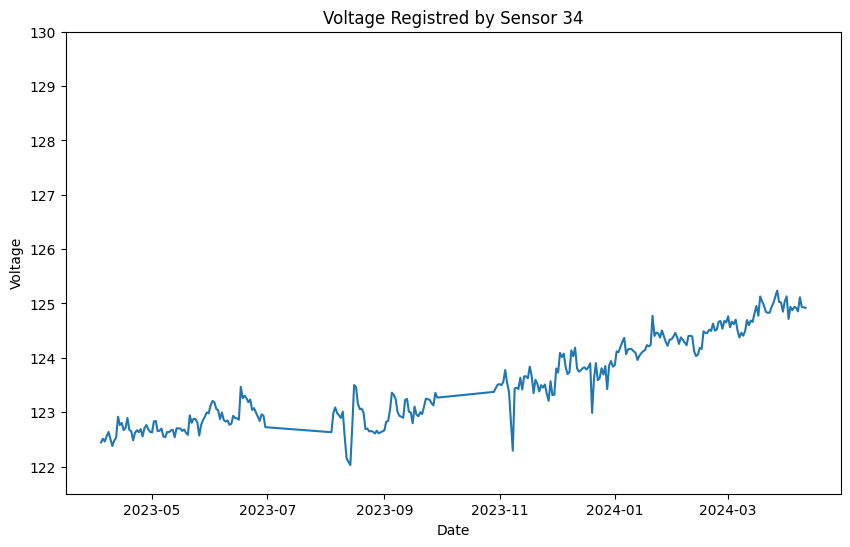

In [51]:
plt.figure(figsize=(10, 6))
sns.lineplot(data = average_s34, x='average_daily', y='sensor 34')
plt.title('Voltage Registred by Sensor 34')
plt.ylim(121.5, 130)
plt.xlabel('Date')
plt.ylabel('Voltage')
plt.show()

In [52]:
average_s34['diff'] = average_s34['sensor 34'].diff()
average_s34.dropna(inplace=True)
average_s34.head(3)

,average_daily,sensor 34,diff
1,2023-04-05,122.511457,0.067008
2,2023-04-06,122.462247,-0.049210
3,2023-04-07,122.558795,0.096548


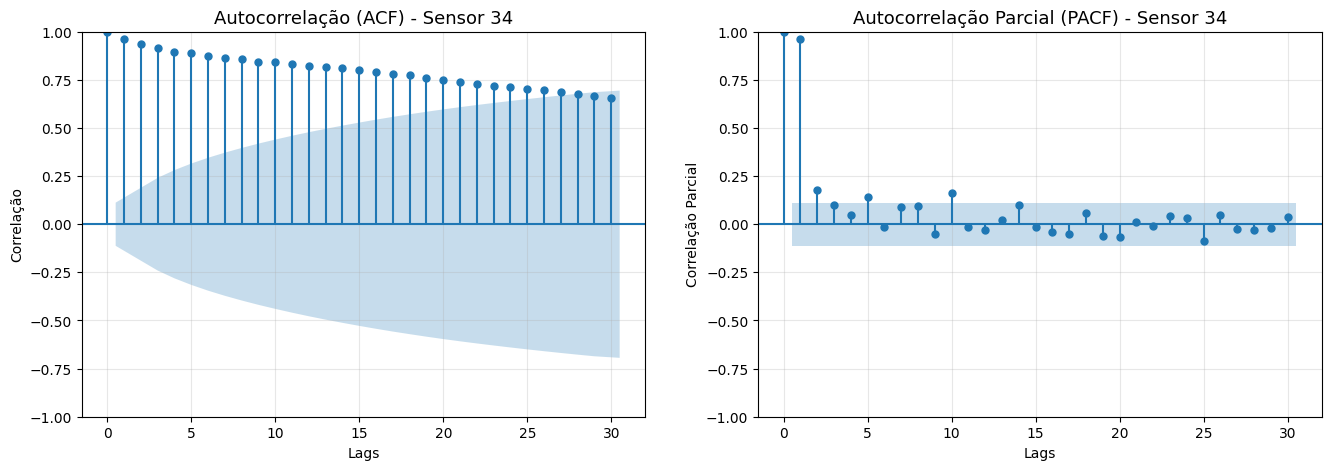

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(average_s34['sensor 34'], lags=30, ax=axes[0], alpha=0.05)
axes[0].set_title('Autocorrelação (ACF) - Sensor 34', fontsize=13)
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Correlação')
axes[0].grid(True, alpha=0.3)

plot_pacf(average_s34['sensor 34'], lags=30, method='yw', ax=axes[1], alpha=0.05)
axes[1].set_title('Autocorrelação Parcial (PACF) - Sensor 34', fontsize=13)
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Correlação Parcial')
axes[1].grid(True, alpha=0.3)

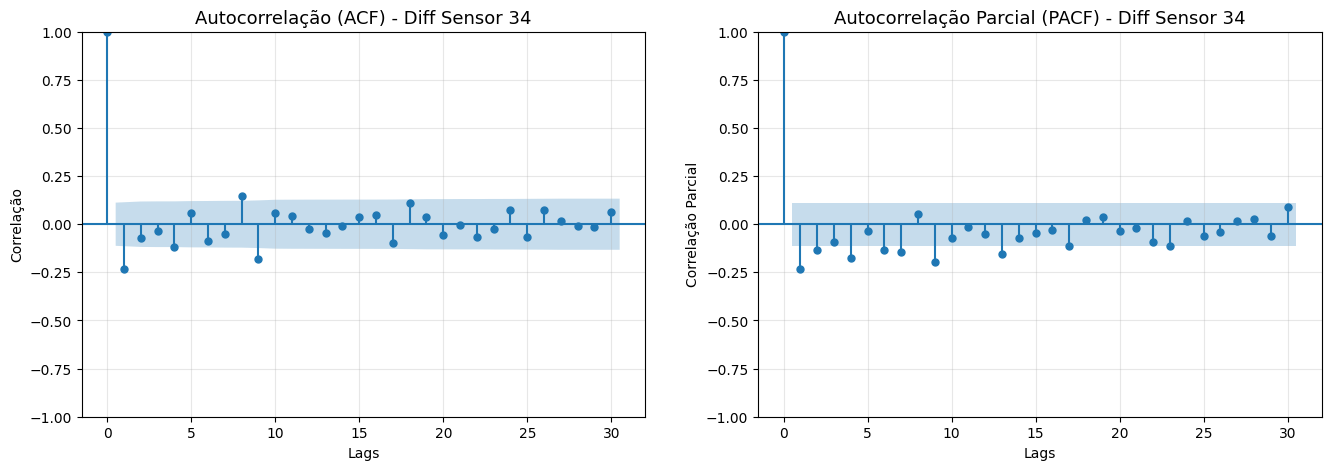

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(average_s34['diff'], lags=30, ax=axes[0], alpha=0.05)
axes[0].set_title('Autocorrelação (ACF) - Diff Sensor 34', fontsize=13)
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Correlação')
axes[0].grid(True, alpha=0.3)

plot_pacf(average_s34['diff'], lags=30, method='yw', ax=axes[1], alpha=0.05)
axes[1].set_title('Autocorrelação Parcial (PACF) - Diff Sensor 34', fontsize=13)
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Correlação Parcial')
axes[1].grid(True, alpha=0.3)

## Features

Separating into test and training sets

In [55]:
for i in range(1, 4, 1):
        average_s34[f'shift_{i}'] = average_s34['sensor 34'].shift(i)
average_s34.dropna(inplace=True)

y = average_s34['sensor 34'].values.reshape(-1, 1).astype('float32')
X = average_s34[[f'shift_{i}' for i in range(1, 4)]].values.astype('float32')  # Usando os valores dos 8 dias anteriores como recursos


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False) #shuffle=False to maintain the time series order


In [56]:
preview = pd.DataFrame(X_train, columns=[f'shift_{i}' for i in range(1, 4)])
preview.head(3)

,shift_1,shift_2,shift_3
0,122.558792,122.462250,122.511459
1,122.635338,122.558792,122.462250
2,122.505692,122.635338,122.558792


In [57]:
X.shape, y.shape

((302, 3), (302, 1))

Normalizando dados

In [58]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) #Evitar datalake

Hiperparâmetros

In [59]:
TAXA_APRENDIZADO = 0.001  # Tamanho do "passo" na otimização (ex: 0.1, 0.01, 0.001)
EPOCAS = 300             # Quantas vezes a rede verá todo o dataset
TAMANHO_LOTE = 10         # Batch size 

Aplicando o treinamento

In [ ]:
#Construção da arquitetura
#Camada de Entrada
model_mlp = Sequential([Dense(32, # 64 Neurônio nesta camada (Z = W*X + b)
                                  input_shape=(3,), # Quantidade de variáveis que vão entrar ( Z = w1*x1 + w2*x2 + b)
                                  activation='relu') ]) # Especificando qual vai ser o tipo de ativação. Ex: reLu, linear, tanh, sigmoid...


#Camada Oculta 1
model_mlp.add(Dense(16, activation='relu'))

#Camada de Saída
model_mlp.add(Dense(1, activation='linear')) # 1 Neurônio nesta camada (Z = W*X + b) --- IGNORE ---, ativação linear para regressão


#Configuração
model_mlp.compile(
    optimizer=Adam(learning_rate=TAXA_APRENDIZADO), #Aplicação do modelo de Gradiente descendente, usando o leanning rate proposto
    loss='mse', # Qual a função da loss. Nesse caso o mse é (Z - F(x1,x2))²
    metrics=['mae'] # Erro Médio Absoluto para termos uma métrica mais legível
)

#Treinamento
historico = model_mlp.fit(
    X_train_scaled, y_train, #Indica quais são as bases
    epochs=EPOCAS, batch_size=TAMANHO_LOTE, #O batch_size é a batelada de cada iteração (epoch) que será calculada
    verbose=1 # Mude para 1 se quiser ver o log de cada época
)

Epoch 1/300


c:\Projeto de Manutenção\Maintenance-prediction\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 15077.0771 - mae: 122.7856   
Epoch 2/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14888.7676 - mae: 122.0136 
Epoch 3/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 14625.2197 - mae: 120.9229 
Epoch 4/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14218.8125 - mae: 119.2156 
Epoch 5/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13635.3984 - mae: 116.7160 
Epoch 6/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12774.1758 - mae: 112.8974 
Epoch 7/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11623.8984 - mae: 107.5577 
Epoch 8/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10153.3154 - mae: 100.2724 
Epoch 9/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8467.0537 - mae: 91.0276 
Epoch 10/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6692.9380 - mae: 79.7869 
Epoch 11/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5052.9951 - mae: 67.4982 
Epoch 12/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - los

In [61]:
model_mlp.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,021 (7.90 KB)

 Trainable params: 673 (2.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,348 (5.27 KB)

In [62]:
# get_weights() retorna uma lista: o primeiro item é a matriz de pesos (W), o segundo é o viés (b)
pesos, vies = model_mlp.get_layer(index=0).get_weights()

print(f"pesos: {pesos.flatten()} e o viés: {vies[0]:.4f}")

pesos: [ 0.37313166 -0.23555337 -0.13266918  0.02022837  0.1444145   0.26160398
  0.42025498 -0.02015237 -0.2859385  -0.15434109  0.03930433  0.20029935
 -0.1464644  -0.27384478 -0.23768033 -0.35833663 -0.41347072 -0.01622163
 -0.29328957 -0.13229322 -0.2565147   0.37320122  0.28247955  0.39552307
  0.33136943 -0.07977826 -0.05505193 -0.35253823  0.33992606 -0.3804064
  0.22865726  0.2163835   0.30033785  0.22925787 -0.27944347 -0.3107693
  0.0622053   0.17174329  0.50665367 -0.3001155  -0.01420109 -0.00183523
 -0.1105159   0.18488455 -0.23881266  0.33476672  0.27889305 -0.49955708
 -0.5082063  -0.16375564  0.16013905 -0.2276951   0.2627404   0.2577824
  0.10363161 -0.24359299 -0.05154527 -0.26821235 -0.17879295  0.4499051
  0.21491192 -0.17897762 -0.05169109 -0.33298698  0.21785365  0.3763076
  0.17820893 -0.03449588  0.3214629   0.09810133  0.69368255  0.11305775
 -0.01185616 -0.14997385  0.08280981  0.09421308  0.11794462  0.26285428
  0.27124503 -0.40786687 -0.5863044  -0.43085137 

In [63]:
medias = scaler.mean_
desvios = scaler.scale_

#w = pesos / desvios
w = pesos / desvios[:, np.newaxis]
b_raw = vies - np.dot(medias, w)

w_escalar = w[0][0]
b_raw_escalar = b_raw[0]

print(f"Pesos desnormalizados: {w.flatten()}")
print(f"Viés desnormalizado: {b_raw_escalar:.4f}")

Pesos desnormalizados: [ 0.6241755  -0.39403421 -0.22192931  0.03383806  0.2415769   0.43761174
  0.70300348 -0.03371093 -0.47831858 -0.25818212  0.06574837  0.33506121
 -0.24500599 -0.45808817 -0.3975922  -0.59942633 -0.69165476 -0.02713558
 -0.49061547 -0.22130041 -0.42909837  0.62429185  0.47253244  0.6616319
  0.55431554 -0.13345326 -0.09209099 -0.58972675  0.5686291  -0.63634471
  0.38249839  0.36196682  0.50412663  0.38481662 -0.46905475 -0.52163613
  0.10441357  0.28827657  0.85043428 -0.5037534  -0.02383698 -0.00308049
 -0.18550445  0.31033459 -0.40085463  0.56191657  0.46813085 -0.83852243
 -0.85304044 -0.27486905  0.26879849 -0.38219345  0.44101812  0.43269595
  0.17394895 -0.40887858 -0.08652037 -0.45020295 -0.30010966  0.75518001
  0.36073649 -0.30041963 -0.08676514 -0.55892923  0.36640537  0.63290713
  0.29972741 -0.05801819  0.54066449  0.16499542  1.16669614  0.19015045
 -0.01994073 -0.25223918  0.13927679  0.15845583  0.19836961  0.44209137
  0.45620368 -0.68598626 -0.9

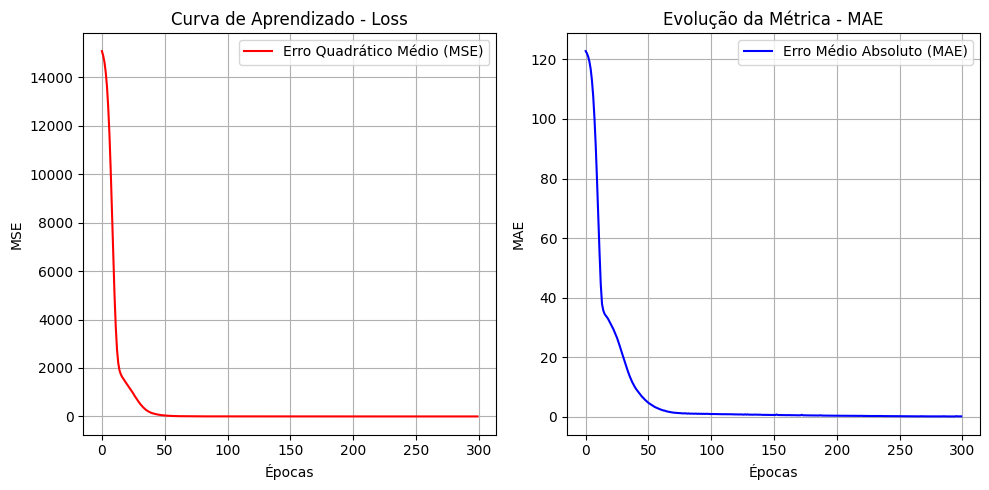

In [64]:
plt.figure(figsize=(10, 5))

# Plotando a Perda (MSE)
plt.subplot(1, 2, 1)
plt.plot(historico.history['loss'], label='Erro Quadrático Médio (MSE)', color='red')
plt.title('Curva de Aprendizado - Loss')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

# Plotando a Métrica (MAE)
plt.subplot(1, 2, 2)
plt.plot(historico.history['mae'], label='Erro Médio Absoluto (MAE)', color='blue')
plt.title('Evolução da Métrica - MAE')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [65]:
erro_simples = model_mlp.evaluate(X_test_scaled, y_test, verbose=0)[1]
print(f"Erro Médio Absoluto (Simples): {erro_simples:.2f}\n")

Erro Médio Absoluto (Simples): 0.99



2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


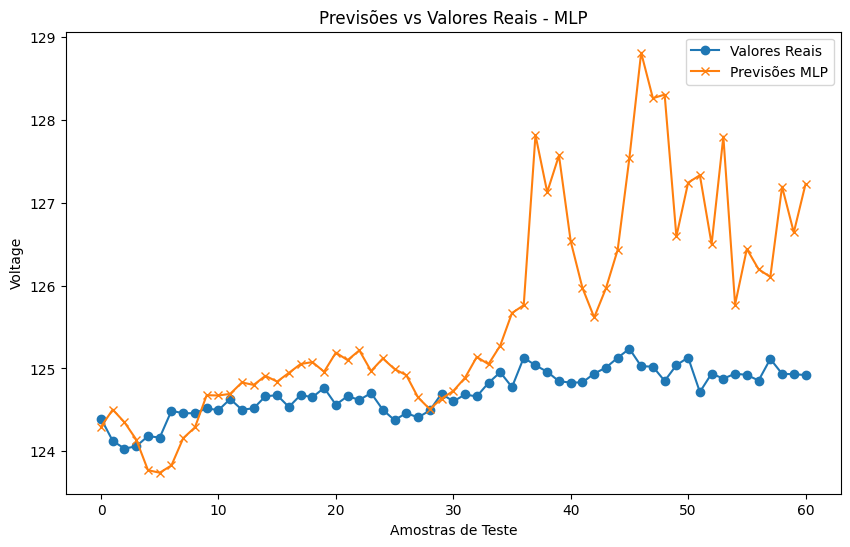

In [71]:
plt.figure(figsize=(10, 6))
y_pred = model_mlp.predict(X_test_scaled)   
plt.plot(y_test, label='Valores Reais', marker='o')
plt.plot(y_pred, label='Previsões MLP', marker='x')
plt.title('Previsões vs Valores Reais - MLP')
plt.xlabel('Amostras de Teste')
plt.ylabel('Voltage')
plt.legend()